# Peek — Product Analyst Data Challenge
## Part 2 — Analysis & Visualization

**Dataset:** `bigquery-public-data.thelook_ecommerce`  ·  **Author:** Abraham Pérez Martínez

Every figure below reads only the cached CSVs in `data/` (produced by `sql/part1_queries.sql`), so this notebook reproduces each chart end-to-end without touching BigQuery. One design system throughout: a colorblind-safe categorical pair (blue / orange), **one axis per panel** (never dual-axis), and a consistent editorial title block.

**Headline:** thelook is a **high-acquisition, low-retention** business. Revenue compounds ~30× across the window, yet ~96% of a month's active customers place no order in the next 90 days, and the share of revenue from returning customers has only recently climbed from near-zero to ~16% (peaking near 20%).

This notebook is the detailed companion to the slide deck: it walks Tasks A–D plus the cohort stretch, states every definition inline, and closes with the leadership questions, dashboard design, and AI-usage notes from the brief.

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

DATA = Path("../data")
CHARTS = Path("charts"); CHARTS.mkdir(exist_ok=True)

# ---- Design tokens (validated dataviz palette; categorical pair passes CVD checks) ----
SURFACE = "#ffffff"   # clean white surface
PANEL   = "#ffffff"
INK     = "#111418"   # primary text
INK2    = "#5b6169"   # secondary text
MUTED   = "#9aa0a8"   # captions / footnotes
GRID    = "#ececef"   # hairline grid
AXIS    = "#d7dade"   # baseline
BLUE    = "#2a78d6"   # categorical slot 1  (returning / revenue)
BLUE_D  = "#1c5aa6"
ORANGE  = "#eb6834"   # categorical slot 2  (new)
RED     = "#e34948"   # negative / churn
GREEN   = "#1a9e5f"   # positive
BLUE_SEQ = LinearSegmentedColormap.from_list(
    "blues", ["#f2f7fd","#d7e7fa","#a9caf3","#6ea9e8","#3987e5","#1f66bd","#123f78"])

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.facecolor": SURFACE, "axes.facecolor": PANEL, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.grid": False, "grid.color": GRID, "grid.linewidth": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.labelsize": 10.5,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.major.size": 0, "ytick.major.size": 0, "xtick.major.pad": 7, "ytick.major.pad": 6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.pad_inches": 0.35,
    "lines.linewidth": 2.4, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 10,
})

KUSD = mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k")
USD  = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
PCT  = mticker.PercentFormatter()

def panel(ax, title, ygrid=True):
    """Apply the shared panel look: left title, hairline y-grid, no left spine."""
    ax.set_title(title, loc="left", pad=10, fontsize=12, fontweight="bold", color=INK)
    if ygrid:
        ax.grid(True, axis="y")
    ax.set_axisbelow(True)
    ax.margins(x=0)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    return ax

def titleblock(fig, headline, subtitle=None,
               source="Source: bigquery-public-data.thelook_ecommerce · completed orders only "
                      "(status = 'Complete', not returned)"):
    """Editorial title block: bold headline + muted subtitle at top-left, source footer bottom-left."""
    fig.text(0.012, 0.985, headline, ha="left", va="top", fontsize=16.5, fontweight="bold", color=INK)
    if subtitle:
        fig.text(0.012, 0.928, subtitle, ha="left", va="top", fontsize=11, color=INK2)
    fig.text(0.012, 0.008, source, ha="left", va="bottom", fontsize=8.5, color=MUTED)

def endpoint(ax, x, y, text, color, dy=8):
    """Dot + label on the last data point to anchor the eye."""
    ax.plot([x], [y], "o", ms=7, color=color, zorder=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.annotate(text, (x, y), color=color, fontweight="bold", fontsize=10.5,
                xytext=(8, dy), textcoords="offset points", va="center")

def load(name, parse=("month",)):
    df = pd.read_csv(DATA / name)
    for c in parse:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])
    return df

a   = load("taskA_monthly_financials.csv")
b   = load("taskB_new_vs_returning.csv")
c   = load("taskC_churn_90d.csv")
d1  = load("taskD1_monthly_trend.csv")
d2  = load("taskD2_prepost_valueband.csv")
coh = load("taskC_cohort_retention.csv", parse=("cohort_month",))
print("Loaded:", {k: v.shape for k, v in dict(A=a, B=b, C=c, D1=d1, D2=d2, cohort=coh).items()})

Loaded: {'A': (91, 6), 'B': (91, 7), 'C': (88, 4), 'D1': (91, 6), 'D2': (4, 7), 'cohort': (1643, 5)}


## 0 · Definitions & assumptions

Stated up front so every number below is unambiguous. These mirror the brief's conventions and the README.

| Concept | Definition used here |
|---|---|
| **Completed sale** | `order_items.status = 'Complete'` **and** `returned_at IS NULL`. Every revenue / order / margin figure uses only these. |
| **Revenue** | `SUM(sale_price)` of completed items. **Gross profit** = revenue − `inventory_items.cost`; **margin** = gross profit ÷ revenue. |
| **Month** | `DATE_TRUNC(DATE(created_at), MONTH)`. Window = **2019-02 → 2026-08**, 91 fully-complete months; the current partial month is dropped so growth and trend lines aren't distorted by an unfinished month. |
| **Active customer (month)** | ≥ 1 completed order in that calendar month. |
| **New vs returning** | keyed on each customer's **first-ever completed order**: an order is *new* if it falls in that customer's first-purchase month, otherwise *returning*. `%_revenue_from_returning` = returning revenue ÷ total. |
| **90-day churn** | of the customers active in month *M*, the share with **no** completed order in the following 90 days. Reported only for months with a fully-observed 90-day forward window. |
| **Cohort retention** | rows = first-purchase month, columns = months since first purchase, value = share of that cohort active at the offset. |

**Known limitation (churn).** This 90-day definition is calendar-anchored and binary. In production I'd anchor the window to each customer's *own* last order (rolling) and treat churn as a survival / hazard problem rather than a fixed-window flag — the current version over-counts "churn" for customers who simply buy on a cadence longer than 90 days.

## 1 · New vs Returning revenue mix

Two single-axis panels sharing the timeline: **absolute** stacked revenue (growth + composition) and
the **share** of revenue from returning customers. Acquisition (orange) carries the top line; the
returning share (blue) has only recently reached ~16% (peaking near 20%).

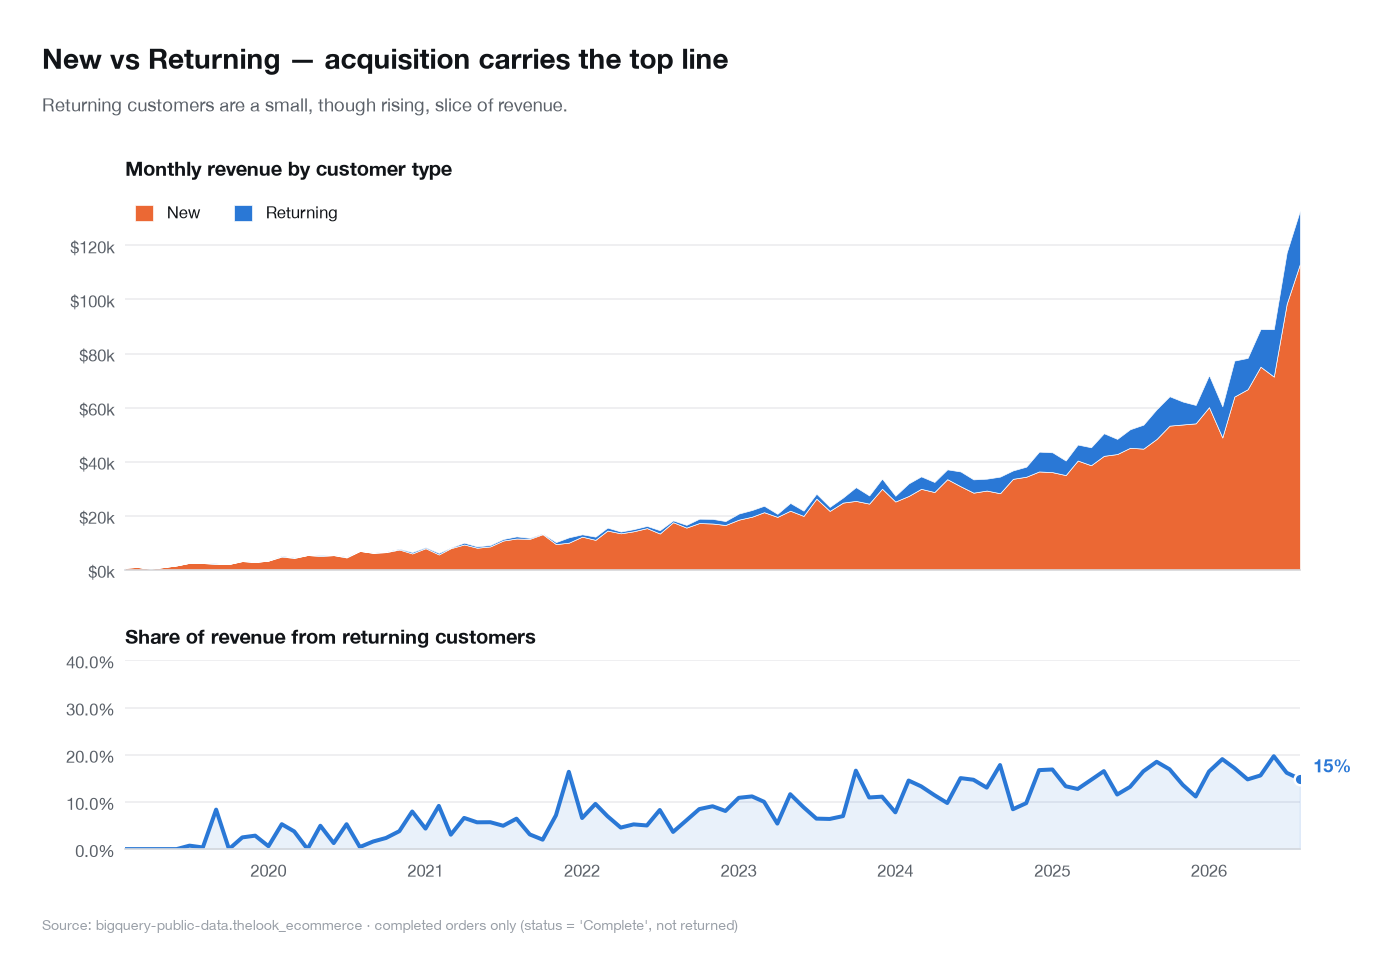

In [2]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7.6), sharex=True, gridspec_kw={"height_ratios": [2, 1], "hspace": 0.32})
fig.subplots_adjust(top=0.82, bottom=0.10, left=0.075, right=0.965)

m = b["month"]
panel(ax1, "Monthly revenue by customer type")
ax1.stackplot(m, b["revenue_new"], b["revenue_returning"],
              colors=[ORANGE, BLUE], labels=["New", "Returning"], edgecolor=SURFACE, linewidth=0.4)
ax1.yaxis.set_major_formatter(KUSD)
ax1.legend(loc="upper left", ncol=2, handlelength=1.1, handleheight=1.1, borderaxespad=0.2)

panel(ax2, "Share of revenue from returning customers")
ax2.plot(m, b["pct_rev_returning"]*100, color=BLUE)
ax2.fill_between(m, b["pct_rev_returning"]*100, color=BLUE, alpha=0.10)
ax2.yaxis.set_major_formatter(PCT)
ax2.set_ylim(0, max(40, b["pct_rev_returning"].max()*100*1.25))
last = b.dropna(subset=["pct_rev_returning"]).iloc[-1]
endpoint(ax2, last["month"], last["pct_rev_returning"]*100, f"{last['pct_rev_returning']*100:.0f}%", BLUE)

titleblock(fig, "New vs Returning — acquisition carries the top line",
           "Returning customers are a small, though rising, slice of revenue.")
fig.savefig(CHARTS/"01_new_vs_returning.png"); plt.show()

## 2 · Financial health — revenue, orders, MoM growth

Three stacked single-axis panels on one timeline. Revenue and completed orders both compound; MoM
growth swings compress as the base matures (green = up month, red = down).

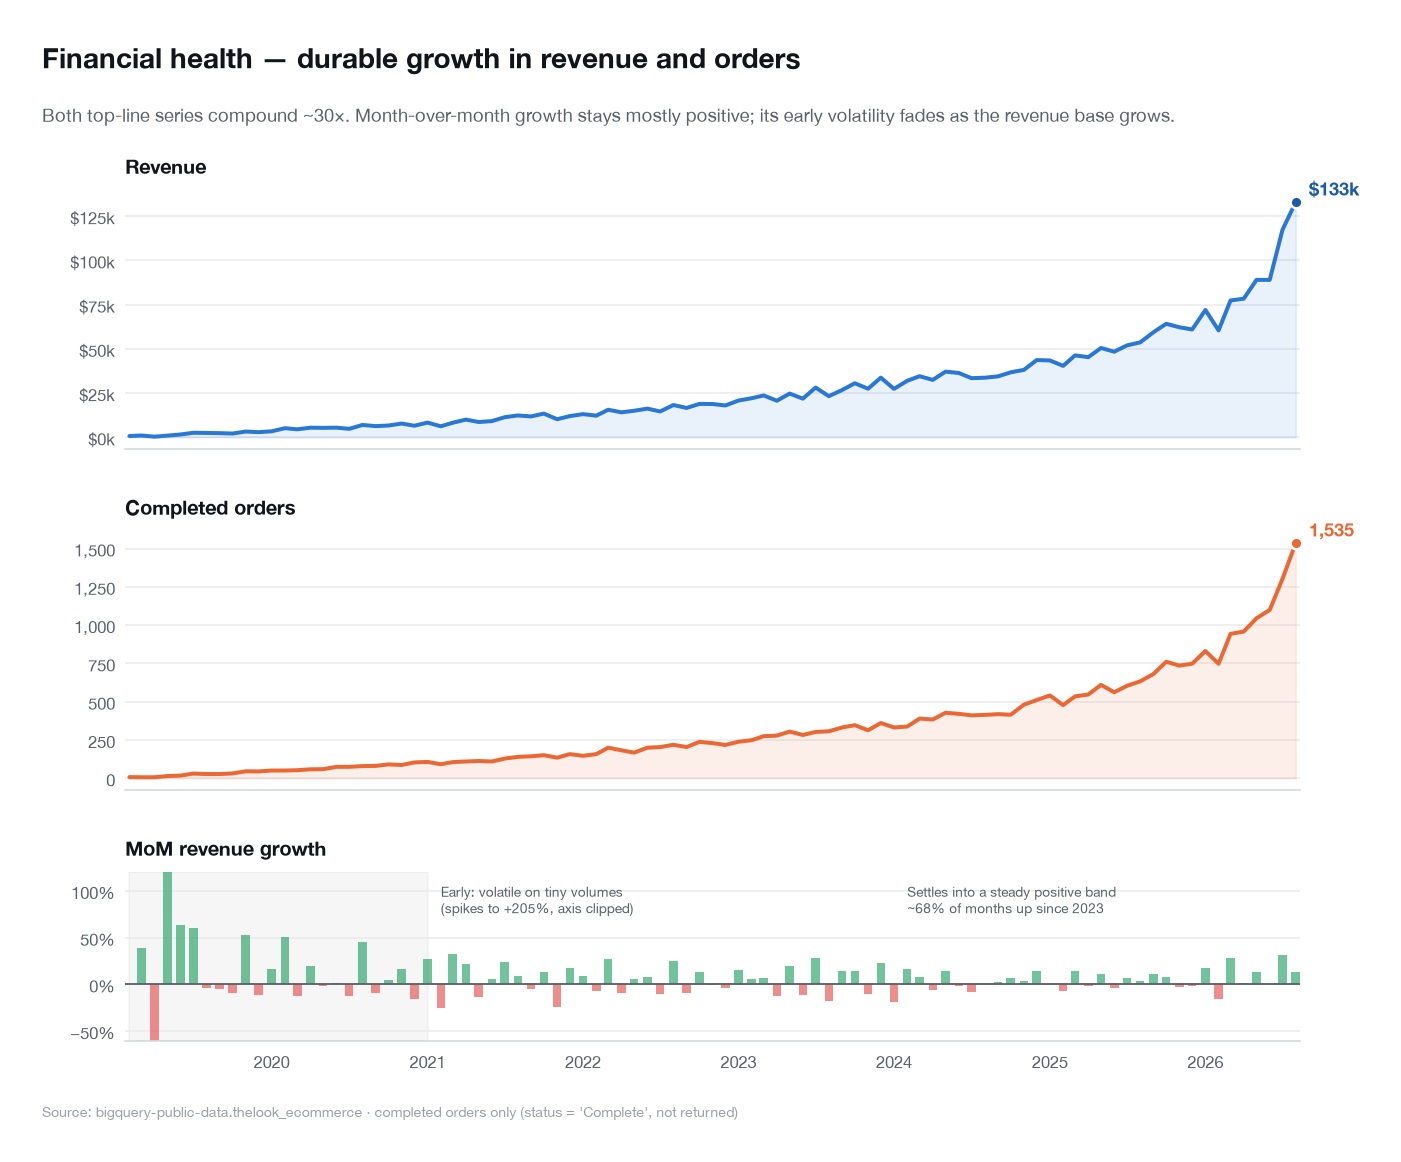

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(11, 9.2), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1.3], "hspace": 0.36})
fig.subplots_adjust(top=0.85, bottom=0.08, left=0.075, right=0.965)

panel(ax1, "Revenue")
ax1.plot(a["month"], a["revenue"], color=BLUE)
ax1.fill_between(a["month"], a["revenue"], color=BLUE, alpha=0.10)
ax1.yaxis.set_major_formatter(KUSD)
endpoint(ax1, a["month"].iloc[-1], a["revenue"].iloc[-1], f"${a['revenue'].iloc[-1]/1000:,.0f}k", BLUE_D)

panel(ax2, "Completed orders")
ax2.plot(a["month"], a["orders"], color=ORANGE)
ax2.fill_between(a["month"], a["orders"], color=ORANGE, alpha=0.10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
endpoint(ax2, a["month"].iloc[-1], a["orders"].iloc[-1], f"{a['orders'].iloc[-1]:,.0f}", ORANGE)

panel(ax3, "MoM revenue growth", ygrid=True)
g = (a["mom_revenue_growth"]*100).fillna(0)
# mark the volatile early era, then draw bars as muted texture over it
ax3.axvspan(a["month"].iloc[0], pd.Timestamp("2021-01-01"), color=INK, alpha=0.035, zorder=0)
ax3.bar(a["month"], g, width=20, color=[GREEN if v >= 0 else RED for v in g], alpha=0.62, zorder=2)
ax3.axhline(0, color=INK2, linewidth=1.1, zorder=3)
ax3.yaxis.set_major_formatter(PCT)
ax3.set_ylim(-60, 120)
# the honest read: swings shrink as the base grows; the axis is clipped, said out loud
ax3.annotate("Early: volatile on tiny volumes\n(spikes to +205%, axis clipped)",
             (pd.Timestamp("2021-02-01"), 108), fontsize=8.2, color=INK2, va="top", ha="left")
ax3.annotate("Settles into a steady positive band\n~68% of months up since 2023",
             (pd.Timestamp("2024-02-01"), 108), fontsize=8.2, color=INK2, va="top", ha="left")

titleblock(fig, "Financial health — durable growth in revenue and orders",
           "Both top-line series compound ~30×. Month-over-month growth stays mostly positive; "
           "its early volatility fades as the revenue base grows.")
fig.savefig(CHARTS/"02_revenue_orders_mom.png"); plt.show()

**Task A deliverable — one row per month.** The panel above is the visual; here is the underlying table with all six required fields (`month, revenue, orders, units, aov, MoM revenue growth`). Showing the last 8 months; the full series is 91 rows.

In [4]:
taskA = a.copy()
taskA["month"] = taskA["month"].dt.strftime("%Y-%m")
taskA["aov"] = taskA["aov"].round(2)
taskA["MoM growth %"] = (taskA["mom_revenue_growth"] * 100).round(1)
taskA = taskA[["month", "revenue", "orders", "units", "aov", "MoM growth %"]].set_index("month")
taskA.tail(8).style.format({"revenue": "${:,.0f}", "aov": "${:,.2f}", "MoM growth %": "{:+.1f}%"})

,revenue,orders,units,aov,MoM growth %
month,,,,,
2026-01,"$72,002",831,1194,$86.65,+18.1%
2026-02,"$60,477",748,1057,$80.85,-16.0%
2026-03,"$77,376",943,1338,$82.05,+27.9%
2026-04,"$78,374",958,1345,$81.81,+1.3%
2026-05,"$89,018",1045,1500,$85.18,+13.6%
2026-06,"$88,993",1099,1551,$80.98,-0.0%
2026-07,"$117,350",1302,1876,$90.13,+31.9%
2026-08,"$132,913",1535,2233,$86.59,+13.3%


## 3 · Retention problem — churn vs revenue

The headline tension: revenue scales ~30× while 90-day churn barely moves off ~96%. Growth is almost
entirely new customers, not repeat behavior. Churn is shown only for months with a fully-observed
90-day forward window.

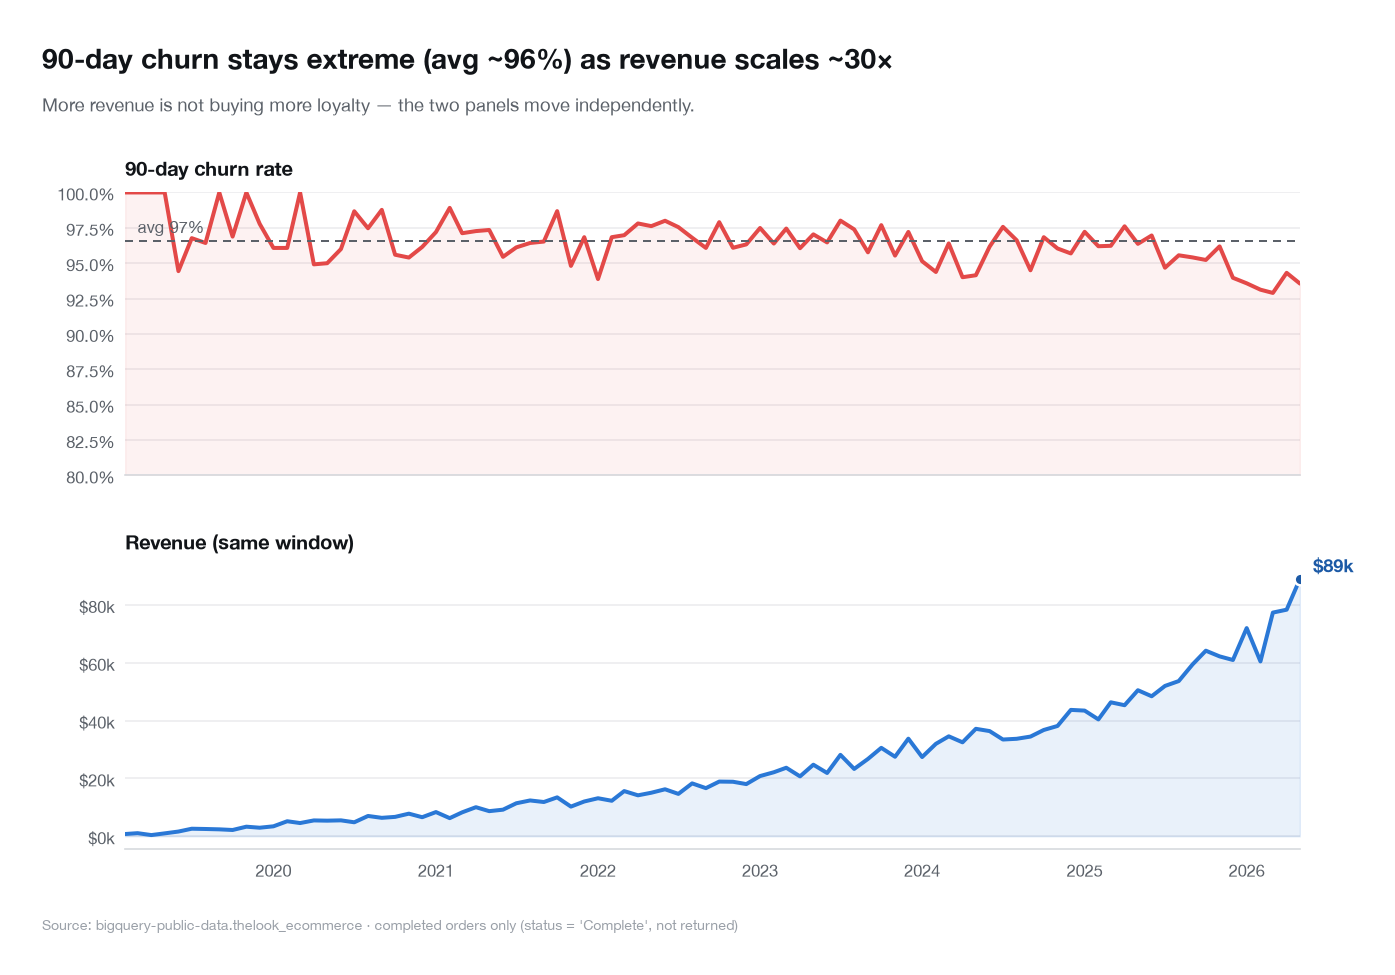

In [5]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7.6), sharex=True, gridspec_kw={"hspace": 0.32})
fig.subplots_adjust(top=0.82, bottom=0.10, left=0.075, right=0.965)

panel(ax1, "90-day churn rate")
ax1.plot(c["month"], c["churn_rate_90d"]*100, color=RED)
ax1.fill_between(c["month"], c["churn_rate_90d"]*100, 80, color=RED, alpha=0.07)
ax1.yaxis.set_major_formatter(PCT); ax1.set_ylim(80, 100)
avg = c["churn_rate_90d"].mean()*100
ax1.axhline(avg, color=INK2, ls=(0, (4, 3)), lw=1.2)
ax1.annotate(f"avg {avg:.0f}%", (c["month"].iloc[1], avg), color=INK2, fontsize=10,
             xytext=(0, 5), textcoords="offset points")

panel(ax2, "Revenue (same window)")
cr = a[a["month"].isin(c["month"])]
ax2.plot(cr["month"], cr["revenue"], color=BLUE)
ax2.fill_between(cr["month"], cr["revenue"], color=BLUE, alpha=0.10)
ax2.yaxis.set_major_formatter(KUSD)
endpoint(ax2, cr["month"].iloc[-1], cr["revenue"].iloc[-1], f"${cr['revenue'].iloc[-1]/1000:,.0f}k", BLUE_D)

titleblock(fig, "90-day churn stays extreme (avg ~96%) as revenue scales ~30×",
           "More revenue is not buying more loyalty — the two panels move independently.")
fig.savefig(CHARTS/"03_churn_vs_revenue.png"); plt.show()

## 4 · Free-shipping impact — analysis scaffold (illustrative)

**The policy is hypothetical and the date is prescribed by the brief:** *"on **2022-01-15**, the business launched free shipping for orders over \$100."* The dataset has **no** `shipping_fee` field and does not reflect this change, so the goal here is **not** a measured effect — it is the *analysis structure* I'd use to read one, which is exactly what the brief asks for ("how you'd structure an impact analysis for a product change").

**Why these two segments (this is the analytical choice we make).** The policy only touches orders **≥ \$100**, so I use them as the **treatment** group and orders **< \$100** as the **control** — the same above/below-\$100 split the brief suggests. Both groups sit in the same store, same calendar, same macro trend, so anything that moves *both* of them (seasonality, catalog changes, inflation) is shared and cancels out.

**Why difference-in-differences.** Comparing treatment before vs after *on its own* would confound the policy with the general time trend. DiD subtracts the control's own pre→post change, which absorbs that shared trend:

$$\text{effect} \;=\; \big(\text{AOV}^{\ge 100}_{\,post}-\text{AOV}^{\ge 100}_{\,pre}\big)\;-\;\big(\text{AOV}^{<100}_{\,post}-\text{AOV}^{<100}_{\,pre}\big)$$

Whatever is left after that subtraction is what's attributable to the policy.

**What we expect — and what it means.** Because the feature isn't in the data, the bands are **flat by construction** and the differenced effect lands at ≈ \$0. That is the honest outcome: a correct *null* on synthetic data, not a fabricated lift. The deliverable is the **frame** — the day a real `shipping_fee` and a launch flag exist, this same query returns a real causal read. **Additional data needed to do this for real:** order-level `shipping_fee` / free-shipping flag, promo exposure, and ideally a randomized **holdout** so "treatment" isn't just a proxy for "large basket."

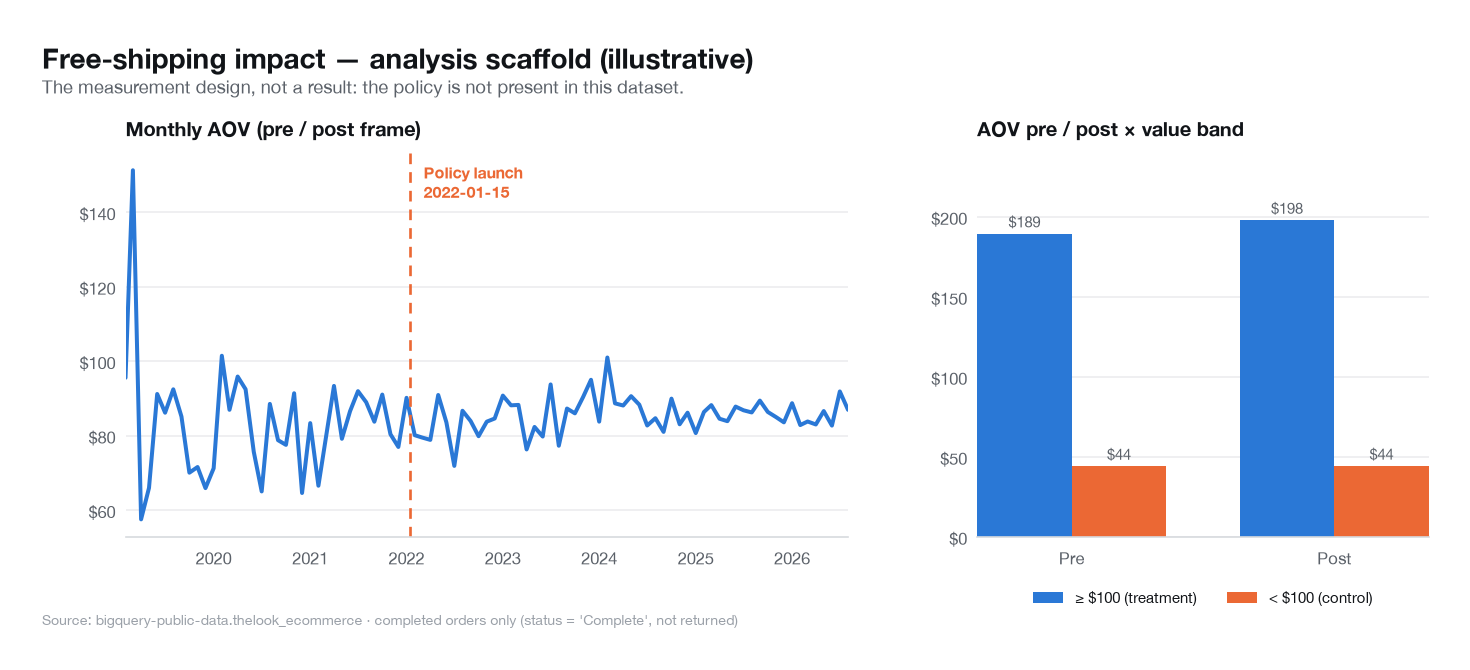

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.0), gridspec_kw={"width_ratios": [1.6, 1], "wspace": 0.22})
fig.subplots_adjust(top=0.80, bottom=0.16, left=0.07, right=0.975)
policy = pd.Timestamp("2022-01-15")

panel(ax1, "Monthly AOV (pre / post frame)")
ax1.plot(d1["month"], d1["aov"], color=BLUE)
ax1.axvline(policy, color=ORANGE, ls=(0, (4, 3)), lw=1.6)
ax1.annotate("Policy launch\n2022-01-15", (policy, ax1.get_ylim()[1]), color=ORANGE,
             xytext=(8, -6), textcoords="offset points", va="top", fontsize=9.5, fontweight="bold")
ax1.yaxis.set_major_formatter(USD)

panel(ax2, "AOV pre / post × value band", ygrid=True)
piv = d2.pivot(index="period", columns="value_band", values="aov").reindex(["pre", "post"])
x = range(len(piv)); w = 0.36
bars1 = ax2.bar([i-w/2 for i in x], piv["gte_100"], width=w, color=BLUE,   label="≥ $100 (treatment)")
bars2 = ax2.bar([i+w/2 for i in x], piv["lt_100"],  width=w, color=ORANGE, label="< $100 (control)")
ax2.set_xticks(list(x)); ax2.set_xticklabels(["Pre", "Post"])
ax2.yaxis.set_major_formatter(USD); ax2.set_ylim(0, 240)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, fontsize=9)
for i in x:
    ax2.annotate(f"${piv['gte_100'].iloc[i]:,.0f}", (i-w/2, piv["gte_100"].iloc[i]),
                 ha="center", va="bottom", fontsize=9, color=INK2, xytext=(0, 2), textcoords="offset points")
    ax2.annotate(f"${piv['lt_100'].iloc[i]:,.0f}", (i+w/2, piv["lt_100"].iloc[i]),
                 ha="center", va="bottom", fontsize=9, color=INK2, xytext=(0, 2), textcoords="offset points")

titleblock(fig, "Free-shipping impact — analysis scaffold (illustrative)",
           "The measurement design, not a result: the policy is not present in this dataset.")
fig.savefig(CHARTS/"04_free_shipping_impact.png"); plt.show()

## 5 · Cohort retention (stretch)

Two views of the **same** fact, built so the pattern is impossible to miss.

- **Top — the average retention curve.** Of everyone who makes a first purchase (month 0 = 100% *by definition*), only ~3% place another completed order the next month, and it flattens near ~1% after. That drop is the whole story.
- **Bottom — the cohort grid.** One row per first-purchase month; **read a row left → right** to follow that group over time. The dark 100% column on the left is the anchor; every row collapses to near-white by month 1 — so the cliff isn't a quirk of one month, it's structural.

*How to read the shape:* the ragged right edge is expected — newer cohorts have simply had fewer months to be observed, not worse retention. Recent cohorts (2024–2026) are shown for legibility; the full table is 91 cohorts.

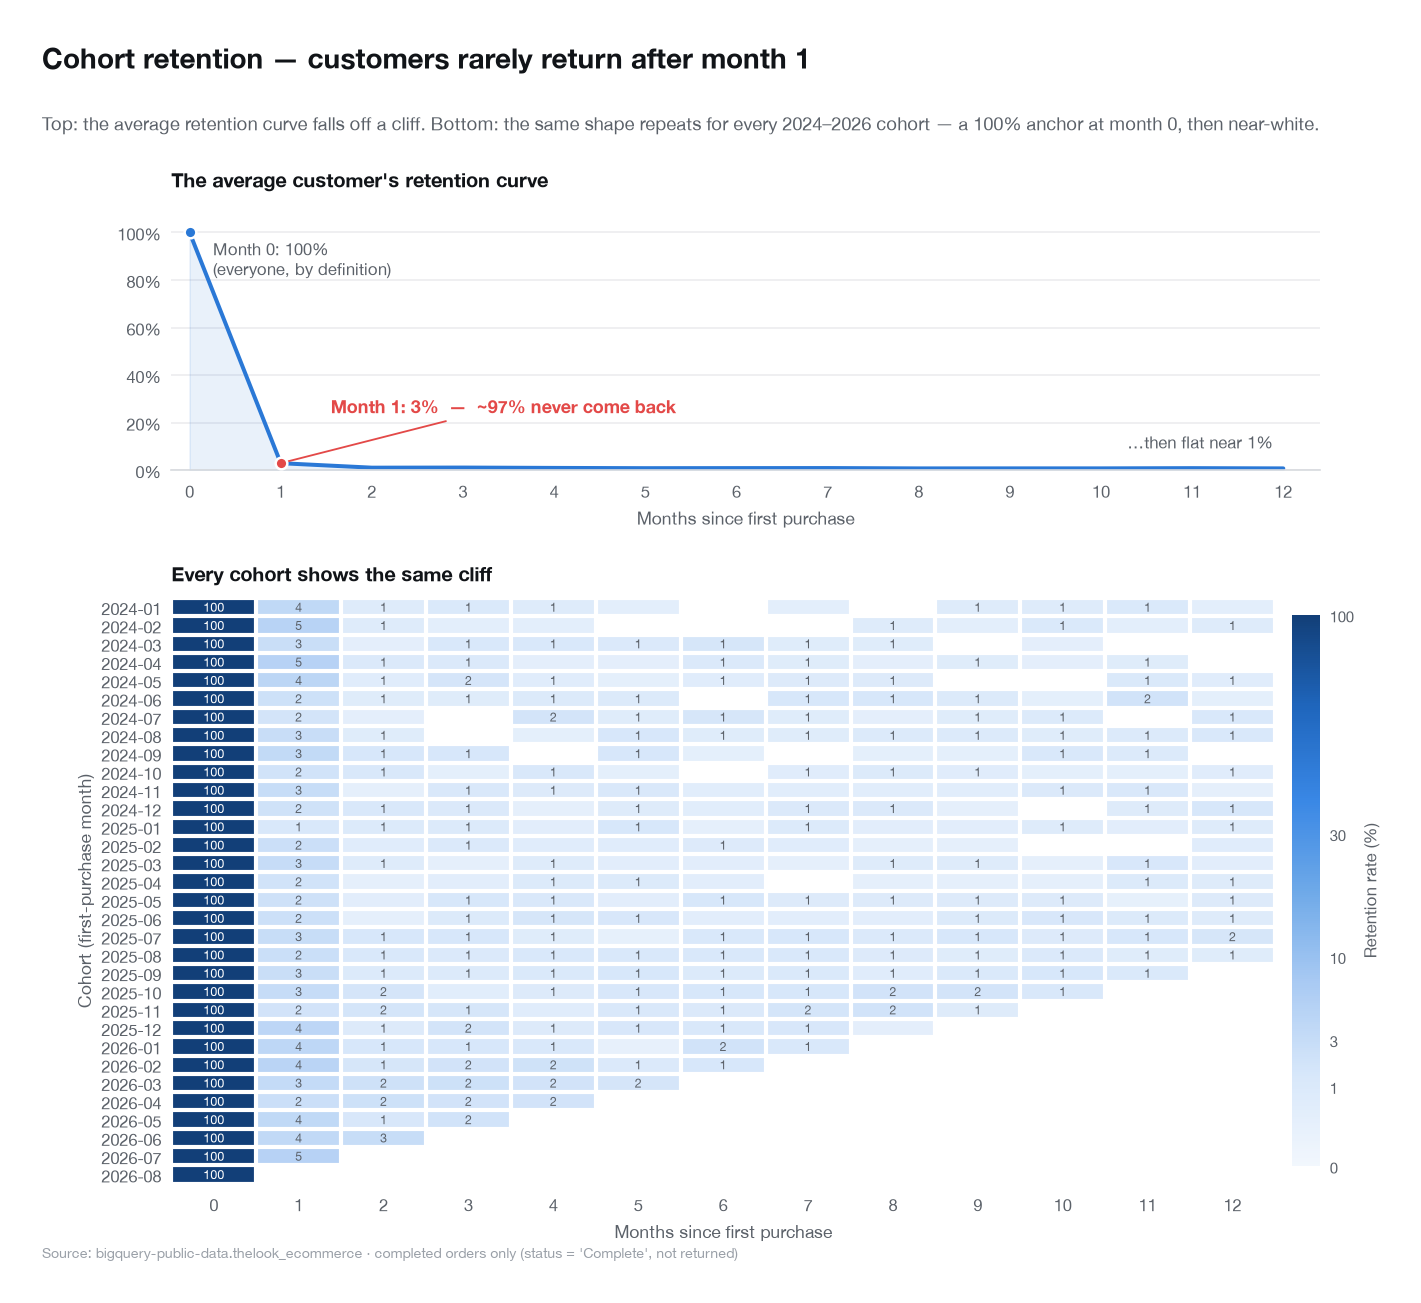

In [7]:
import numpy as np
from matplotlib.colors import PowerNorm

# ---- (1) Average retention curve: what happens to a typical cohort, month by month ----
cur = coh[coh["month_offset"] <= 12].copy()
curve = (cur.groupby("month_offset")
            .apply(lambda g: np.average(g["retention_rate"], weights=g["cohort_size"]),
                   include_groups=False) * 100)
x = curve.index.to_numpy(); y = curve.to_numpy()

# ---- (2) Cohort grid, WITH the month-0 anchor so the cliff has a reference point ----
recent = coh[(coh["cohort_month"] >= "2024-01-01") & (coh["month_offset"].between(0, 12))].copy()
piv = recent.pivot(index="cohort_month", columns="month_offset", values="retention_rate") * 100

fig, (axc, axh) = plt.subplots(2, 1, figsize=(11, 10.4), height_ratios=[1, 2.2],
                               gridspec_kw=dict(hspace=0.30))
fig.subplots_adjust(top=0.855, bottom=0.07, left=0.11, right=0.98)

# --- Panel 1: the curve ---
axc.fill_between(x, y, color=BLUE, alpha=0.10, zorder=1)
axc.plot(x, y, color=BLUE, zorder=2)
panel(axc, "The average customer's retention curve", ygrid=True)
axc.set_xlim(-0.2, 12.4); axc.set_ylim(0, 112)
axc.set_xticks(range(0, 13))
axc.yaxis.set_major_formatter(PCT)
axc.set_xlabel("Months since first purchase")
axc.plot([0], [y[0]], "o", ms=7, color=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=5)
axc.annotate("Month 0: 100%\n(everyone, by definition)", (0, y[0]),
             xytext=(14, -4), textcoords="offset points", fontsize=10, color=INK2, va="top")
axc.plot([1], [y[1]], "o", ms=7, color=RED, markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=6)
axc.annotate(f"Month 1: {y[1]:.0f}%  —  ~{100-y[1]:.0f}% never come back",
             (1, y[1]), xytext=(30, 30), textcoords="offset points",
             fontsize=10.5, fontweight="bold", color=RED,
             arrowprops=dict(arrowstyle="-", color=RED, lw=1.1))
axc.annotate(f"…then flat near {y[-1]:.0f}%", (12, y[-1]),
             xytext=(-6, 12), textcoords="offset points", ha="right", fontsize=10, color=INK2)

# --- Panel 2: the heatmap (nonlinear color keeps the low tail readable) ---
norm = PowerNorm(gamma=0.42, vmin=0, vmax=100)
im = axh.imshow(piv.values, aspect="auto", cmap=BLUE_SEQ, norm=norm)
axh.set_xticks(range(len(piv.columns))); axh.set_xticklabels(piv.columns)
axh.set_yticks(range(len(piv.index)));   axh.set_yticklabels([d.strftime("%Y-%m") for d in piv.index])
axh.set_xlabel("Months since first purchase"); axh.set_ylabel("Cohort (first-purchase month)")
axh.set_title("Every cohort shows the same cliff", loc="left", pad=10,
              fontsize=12, fontweight="bold", color=INK)
for s in axh.spines.values():
    s.set_visible(False)
axh.tick_params(length=0)
axh.set_xticks([i-0.5 for i in range(len(piv.columns)+1)], minor=True)
axh.set_yticks([i-0.5 for i in range(len(piv.index)+1)], minor=True)
axh.grid(which="minor", color=SURFACE, linewidth=2.5)
axh.tick_params(which="minor", length=0)
# label only cells that round to >=1% so the sea of "0"s no longer adds noise
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v) and round(v) >= 1:
            axh.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                     color="white" if norm(v) > 0.55 else INK2)

cb = fig.colorbar(im, ax=axh, fraction=0.024, pad=0.015)
cb.set_label("Retention rate (%)", color=INK2, fontsize=10)
cb.outline.set_visible(False); cb.ax.tick_params(length=0, labelsize=9)
cb.set_ticks([0, 1, 3, 10, 30, 100])

titleblock(fig, "Cohort retention — customers rarely return after month 1",
           "Top: the average retention curve falls off a cliff. Bottom: the same shape repeats "
           "for every 2024–2026 cohort — a 100% anchor at month 0, then near-white.")
fig.savefig(CHARTS/"05_cohort_retention.png"); plt.show()

## 6 · For leadership — the trend, the bet, the dashboard, and AI

**Single most important trend.** The **retention cliff**: ~96% 90-day churn and ~3% month-1 cohort retention. Growth is almost entirely *new* customers — the business is renting revenue, not compounding a base. It matters because a few points of retention compound faster than the same dollars spent re-acquiring customers you already had.

**One business initiative I'd bet on.** A **post-purchase lifecycle program** (onboarding + day-30/60 win-back) aimed at first-time buyers in the highest-margin categories — the segment where a repeat purchase is both most likely and most valuable. **Success metric:** repeat-purchase rate at 30/60/90 days (primary); returning-revenue share and 90-day churn (secondary); read against a **holdout** so we measure *incremental* repeat purchases, not total.

**Core business-health dashboard (5–7 metrics, grouped by lifecycle stage):**

| Stage | Metric(s) |
|---|---|
| Acquisition | New customers / month · (CAC once ad spend joins in) |
| Activation | First-order conversion · time-to-first-order |
| Retention | 90-day churn · month-1 & month-3 cohort retention |
| Monetization | Revenue & MoM growth · AOV · gross margin · returning-revenue share |

**AI in this challenge (Part 3).** I used an AI assistant to scaffold the parameterized SQL and this notebook faster. Example prompt: *"Write BigQuery Standard SQL for monthly new-vs-returning revenue where 'new' = a customer's first-completed-order month; use CTEs and a parameterized date range, no hard-coded cutoffs."* I don't **blindly trust** the output: I re-ran every query against the public dataset, reconciled totals across tasks (e.g. Task A revenue must tie out to Task B's new + returning), sanity-checked signs and magnitudes, and validated the chart palette with a colorblind-safety checker. AI accelerates the boilerplate; the numbers are verified against the data.

## Recommendations

1. **Attack retention, not just the funnel.** With ~96% 90-day churn and ~3% month-1 retention, a few points of retention compound faster than equivalent acquisition spend. Stand up a lifecycle program (post-purchase onboarding, day-30/60 win-back) aimed squarely at the month-0 → month-1 cliff; track repeat-rate at 30/60/90 days as the north-star metric. Pair it with a one-question survey (small incentive, fired at the churn moment) to learn *why* buyers do not return, and test a next-purchase coupon as a **separate lever measured against a holdout** — so we read *incremental* repeats, not redemptions inflated by response and survivorship bias.
2. **Grow returning-revenue share on purpose.** It drifted to ~16% on its own — make it a target. Test loyalty / replenishment nudges on first-time buyers in the highest-margin categories, measuring *incremental* repeat purchases against a holdout.
3. **Instrument before pricing & shipping bets.** Add order-level `shipping_fee` and promo flags, define the launch date, and reserve a holdout — turning a "free shipping over \$100" launch from a guess into a measurable difference-in-differences experiment (see §4).